### Affine Transform(아핀 변환)
- 선형 변환 + 평행 이동 -> 평행과 비율이 보존됨
- 3개의 점이 주어지면 아핀 변환 결정 가능

In [2]:
import cv2
import numpy as np
from PIL import Image

def show(image):
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return Image.fromarray(rgb)

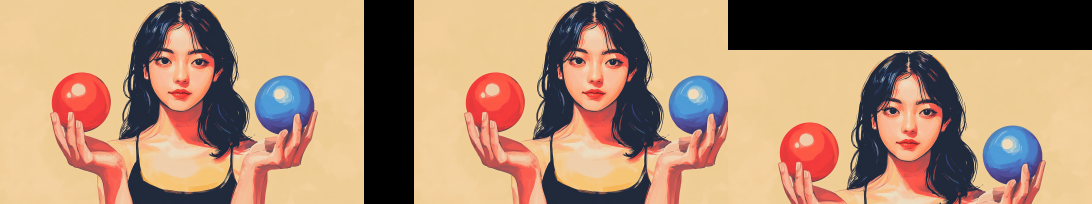

In [7]:
## 평행 이동
image = cv2.imread('../data/balls.png') # 예제 이미지
image = cv2.resize(image, (0, 0), fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)
height, width, channel = image.shape # 이미지의 높이, 너비, 채널 수

# 수평 이동
matrix = np.array([[1, 0, 50], [0, 1, 0]], dtype=np.float32) # x축으로 50픽셀 이동
translated_h = cv2.warpAffine(image, matrix, (width, height)) # 이미지 이동
show(translated_h) # 이미지 출력

# 수직 이동
matrix = np.array([[1, 0, 0], [0, 1, 50]], dtype=np.float32) # y축으로 50픽셀 이동
translated_v = cv2.warpAffine(image, matrix, (width, height)) # 이미지 이동
show(np.concatenate([image, translated_h, translated_v], axis=1)) # 이미지 출력

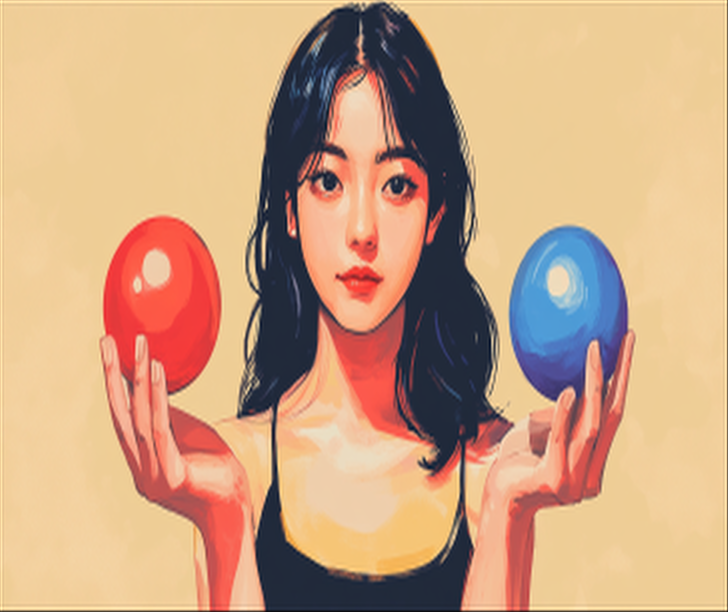

In [8]:
# 확대
wr = 2 # 가로는 2배
hr = 3 # 세로는 3배
matrix = np.array([[wr, 0, 0], [0, hr, 0]], dtype=np.float32)
resized = cv2.warpAffine(image, matrix, 
                         (width * wr, height * hr), # 새로운 크기
                         flags=cv2.INTER_LANCZOS4) # 보간
show(resized)

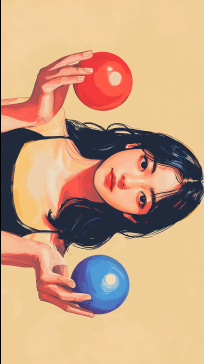

In [9]:
# 회전
matrix = np.array([[0, -1, height], [1, 0, 0]], dtype=np.float32) # 90도 회전 행렬
resized = cv2.warpAffine(image, matrix, (height, width)) # 가로, 세로의 크기가 바뀜
show(resized)

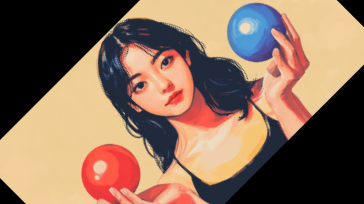

In [10]:
# 회전행렬 계산
center = width // 2, height // 2 # 이미지의 중심 좌표
angle = 45 # 회전 각도
ratio = 1 # 확대 비율
matrix = cv2.getRotationMatrix2D(center, angle, ratio) # 회전 행렬 계산
rotated = cv2.warpAffine(image, matrix, (width, height)) # 이미지 회전
show(rotated) # 이미지 출력

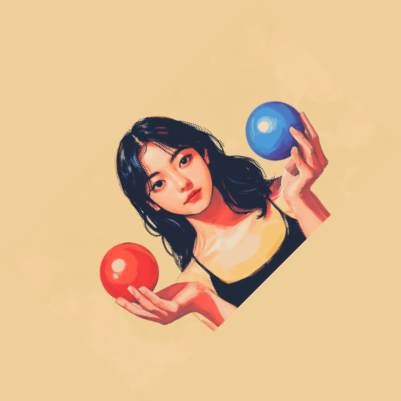

In [11]:
# 크기 맞추기 및 배경 채우기
cos = abs(matrix [0, 0])
sin = abs(matrix [0, 1])
new_width = int((height * sin) + (width * cos)) # 새로운 너비
new_height = int((height * cos) + (width * sin)) # 새로운 높이
image_center = (width // 2, height // 2) # 원본 이미지의 중심 좌표
matrix [0, 2] += (new_width / 2) - image_center [0] # 새로운 x좌표로 이동
matrix [1, 2] += (new_height / 2) - image_center [1] # 새로운 y좌표로 이동

rotated = cv2.warpAffine(
    image, matrix, 
    (new_width, new_height), # 새로운 크기
    borderMode=cv2.BORDER_CONSTANT, # 배경 색은 한 가지로
    borderValue=image[0, 0].tolist()) # 왼쪽 위 (0, 0)의 픽셀 값으로 배경을 채움
show(rotated)

### Perspective transform(투시 변환)
- 아핀 변환에 투시(c) 추가
- 4개의 점이 주어지면 투시 변환 행렬을 결정할 수 있음

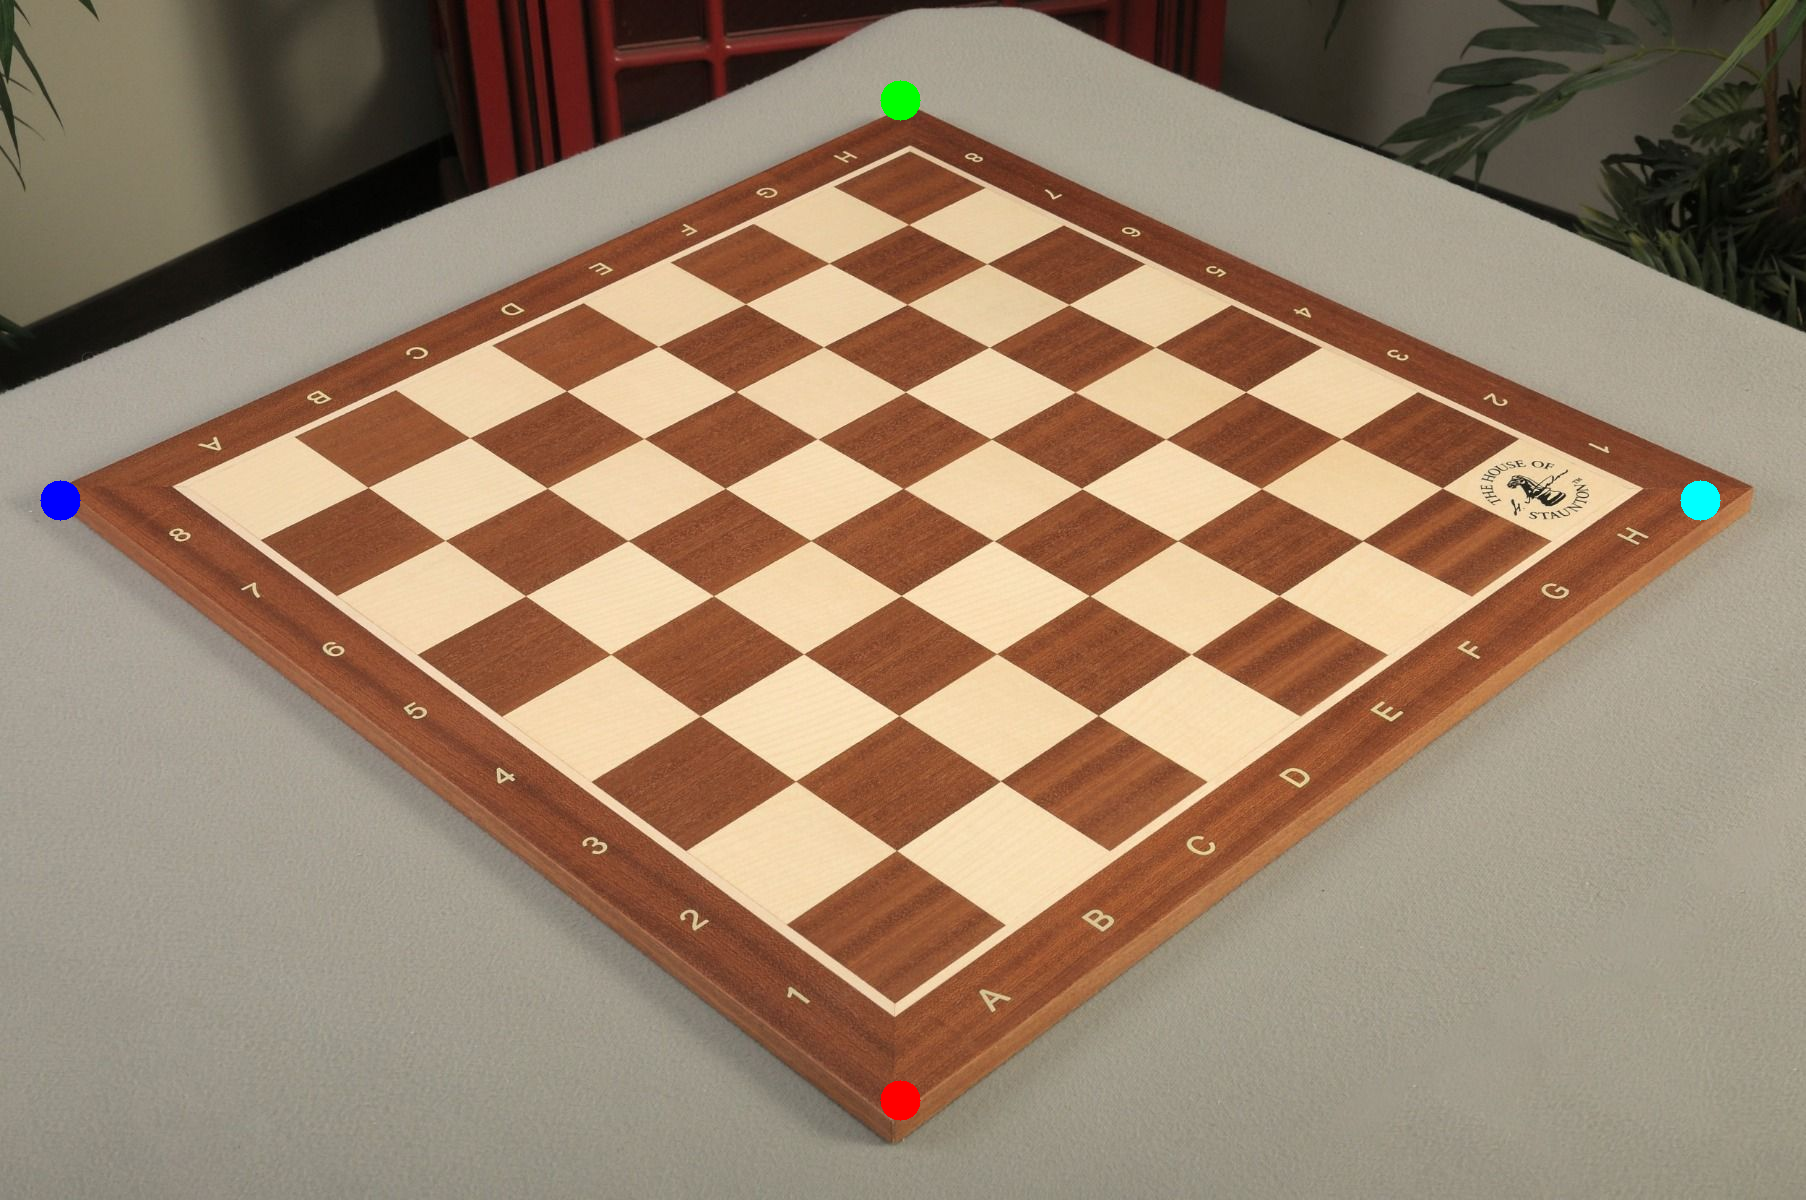

In [3]:
# 체스 보드
src = cv2.imread('../data/chessboard.jpg')

pts1 = np.array([[60, 500],[900, 100], [900,1100],[1700, 500]], dtype=int)
pts2 = np.float32([[0,0],[1000,0],[0,1000], [1000, 1000]])

cv2.circle(src, tuple(pts1[0]), 20, (255,0,0),-1) # 파란색
cv2.circle(src, tuple(pts1[1]), 20, (0,255,0),-1) # 초록색
cv2.circle(src, tuple(pts1[2]), 20, (0,0,255),-1) # 빨간색
cv2.circle(src, tuple(pts1[3]), 20, (255,255,0),-1) # 하늘색
show(src)

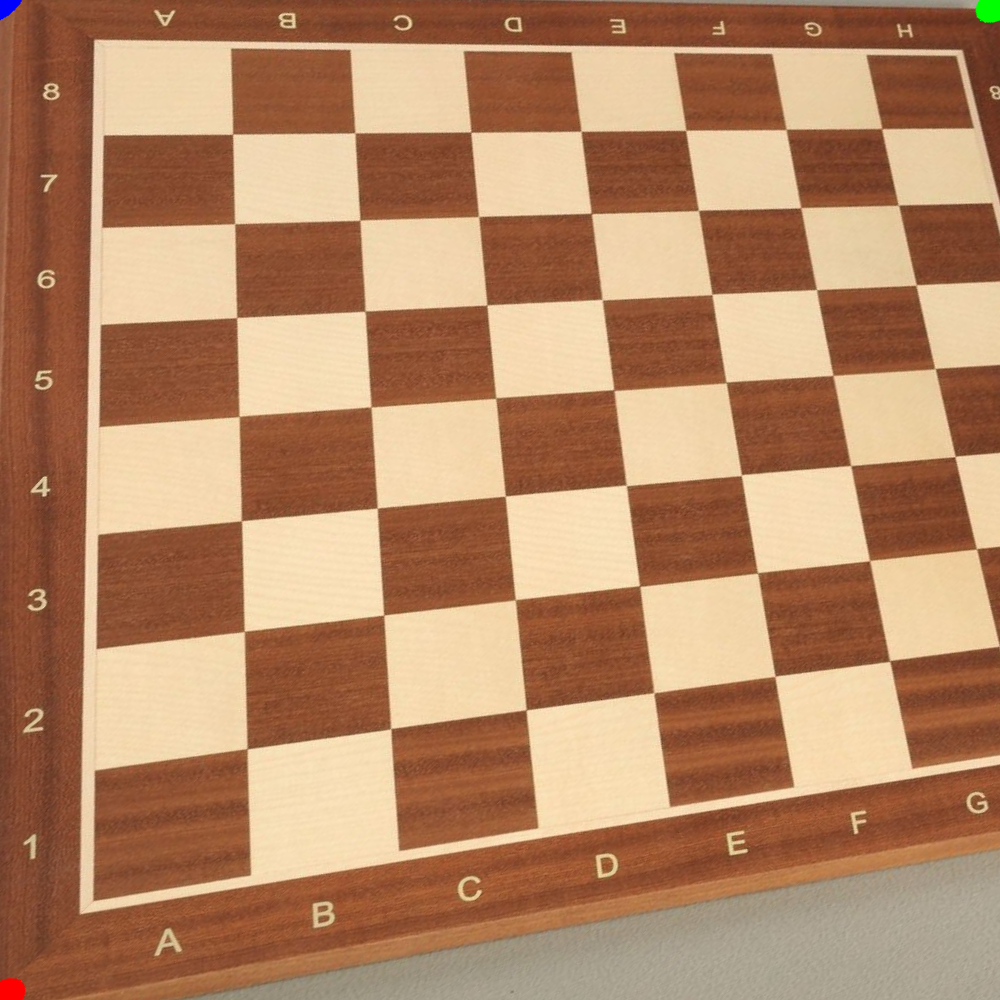

In [ ]:
# 아핀 변환
# 3개의 점으로 변환행렬 결정 가능
src_pts = pts1[:3].astype(np.float32) # 원본의 점 3개
dst_pts = pts2[:3] # 이에 해당하는 변환된 점 3개
matrix = cv2.getAffineTransform(src_pts, dst_pts)
dst = cv2.warpAffine(src, matrix, (1000,1000))
show(dst) # 체스보드를 복원하려면 3차원 회전 필요 -> 투시 변환

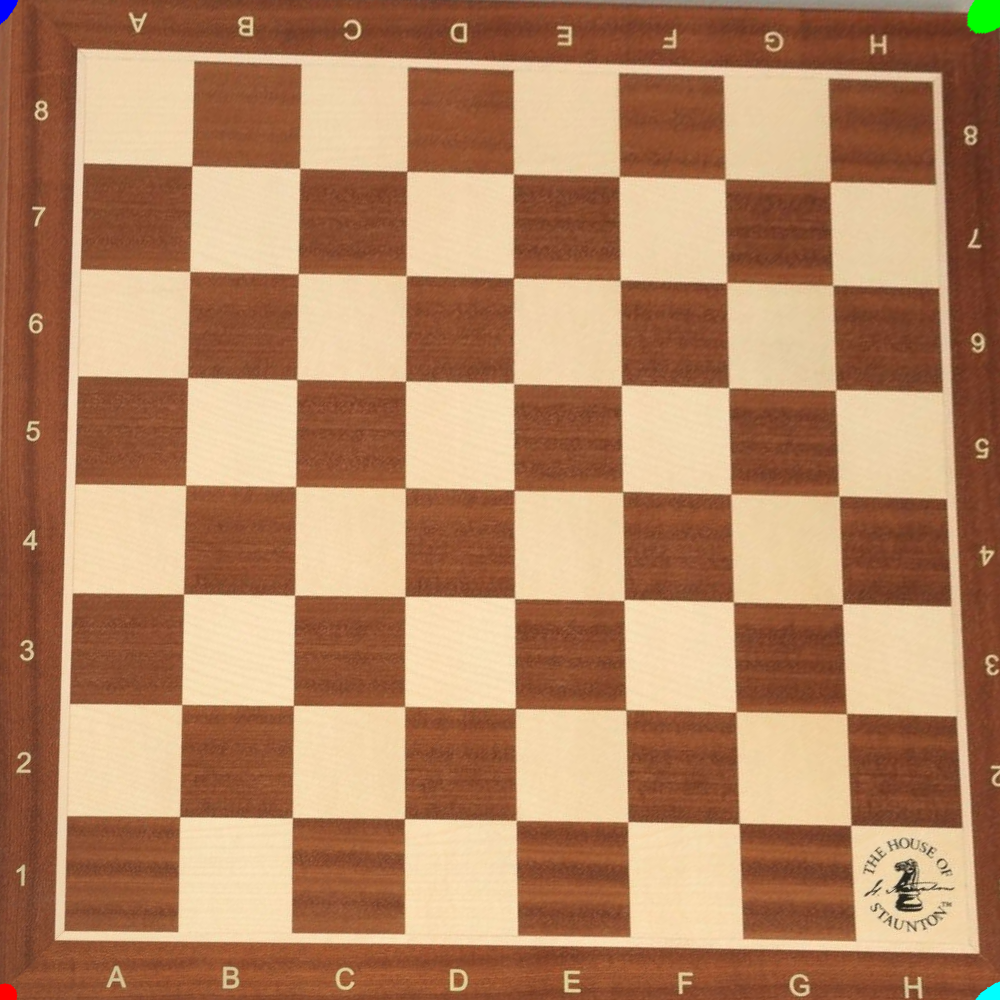

In [ ]:
# 투시 변환
matrix = cv2.getPerspectiveTransform(pts1.astype(np.float32), pts2)# (원본의 점 4개, 이에 해당하는 변환된 점 4개)
dst = cv2.warpPerspective(src, matrix, (1000,1000))
show(dst)